# Structure Matters: Evaluating Schema Representations for Text-to-SQL LLMs
**Hallee Pham | COMP-SCI 5590 (Graduate) - Generative AI & LLMs | UMKC Spring 2026**

My GitHub Repository for this project: (https://github.com/halleepham/text2sql-schema-representation)

---
## Table of Contents

| Section | Description |
|---|---|
| **0. Setup** | Environment setup, dependencies, repo clone, imports, seeds |
| **1. Data & Preprocessing** | Dataset summary, schema formats, prompt structure |
| **2. Layer 1: Base Model Evaluation** | Zero-shot evaluation of LLaMA 3.1 8B across all four schema formats |
| **2.1** | Load base model |
| **2.2** | Pipeline validation |
| **2.3** | Evaluate — Relational schema |
| **2.4** | Evaluate — CREATE TABLE schema |
| **2.5** | Evaluate — JSON schema |
| **2.6** | Evaluate — Natural Language schema |
| **2.7** | Unload base model |
| **2.8** | Layer 1 results summary |
| **3. Layer 2: LoRA Fine-Tuning + Evaluation** | QLoRA adaptation and evaluation for relational and CREATE TABLE schemas |
| **3.0** | LoRA configuration and training control flags |
| **3.1** | Relational schema — train and evaluate |
| **3.2** | CREATE TABLE schema — train and evaluate |
| **3.3** | Layer 2 results summary |
| **4. Demo** | Interactive text-to-SQL demo using the base model and relational schema |

---

## Notebook Overview
This notebook implements and evaluates an end-to-end text-to-SQL pipeline that studies how database schema representation format affects SQL generation performance of LLaMA 3.1 8B.

Four schema formats are evaluated: relational (baseline), CREATE TABLE, JSON, and natural language. Each format is tested on the ATIS airline query dataset using the same 402 held-out test examples, the same evaluation metrics, and the same model — isolating schema format as the sole variable under study.

**Layer 1** evaluates the base model (no fine-tuning) across all four schema formats using zero-shot prompting.

**Layer 2** fine-tunes separate LoRA adapters for the relational and CREATE TABLE formats using QLoRA, then evaluates each adapted model on the same test set.

Results are compared across formats and between base and adapted models using four metrics:
* Exact Match (EM)
* Execution Accuracy (EX)
* Exact Set Match (ESM)
* Record Match Accuracy (RMA)

---

## Before running this notebook:
1. Change Colab runtime to GPU (Runtime -> Change runtime type -> choose a GPU). I used A100 GPU
2. HuggingFace account with approved access to `meta-llama/Llama-3.1-8B`. Create a new token and copy it. Provide token when prompted in the first cell of Section 0 - Setup.

> NO file uploads to Google Colab session is necessary

---

## To run this notebook:
1. By default generation and training are skipped.However, if you would like to run training and generation, set `SKIP_GENERATION` and `SKIP_TRAINING` to `False` in the next two code cells below.
> Note: Generation and training take about 20-30 EACH cell. Setting these flags to `False` is highly unadvised as it will take a long time and use up compute units. You can still see the pull pipeline process without actual generation and training.
1. Run the first code cell of Section 0 (0.1 HuggingFace Login) and enter your token when prompted (**DO NOT PRESS "Run all"**)
2. Click/select the second code cell of Section 0 ( 0.2 "Install Dependencies" cell) so it is the focused cell
3. Click the down arrow next to the "Run all" button (in the top bar)
4. Select 'Run focused cells and all cells below'.
> If this process is not followed, a HuggingFace authenticaton error may occur. If an error does occur, ONLY rerun the code cell with the error and all cells below it.

### Generation Control

* Set `SKIP_GENERATION = False` if you would like to run generation for all four formats and the two LoRA-adapted models.
* When skipped (`SKIP_GENERATION = True`), predictions are loaded from my original inference/training runs, saved in results file instead of rerunning generation.
* Generation takes about 2 hours in total. So it is NOT RECOMMENDED to set to `False`
* Batching was implemented and the time estimate mentioned above is about 2x faster than what it was before
* A inference on a small set are shown in Section 2.2 so the pipeline process is shown without inference on the full dataset.

In [1]:
SKIP_GENERATION = True

### Training Control
* Set `SKIP_TRAINING = True` to load adapters from my original fine-tuning runs.
* See the `adapter/` folder for model weights.


In [2]:
SKIP_TRAINING = True

---
## Section 0 — Setup

### 0.1 HuggingFace Login
* Run this cell **alone** first, then run all below.
* Requires a HuggingFace account with Meta LLaMA 3.1 8B access approved.  
* Request access at: https://huggingface.co/meta-llama/Llama-3.1-8B
* You do NOT need to check "Add token as git credential?"

In [3]:
import warnings
warnings.filterwarnings("ignore") # suppress warnings from HuggingFace for clean output
from huggingface_hub import login

login()

### 0.2 Install Dependencies

In [4]:
# Install dependencies if needed
!pip install -q transformers peft bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.6 MB/s eta 0:00:00


### 0.3 Clone Repository
Downloads all data files, schemas, database, scripts, adapters, and results in one command.  No manual uploads needed.

In [5]:
import os

REPO_URL = "https://github.com/halleepham/text2sql-schema-representation"
REPO_NAME = "text2sql-schema-representation"
REPO_ROOT = f"/content/{REPO_NAME}"

# Clone only if not already present (safe to re-run)
if not os.path.exists(REPO_ROOT):
  !git clone {REPO_URL}
  print(f"Repo cloned to {REPO_ROOT}")
else:
  print(f"Repo already exists at {REPO_ROOT} — skipping clone")

# Verify all key files are present before continuing
print("\nVerifying files...")
required = [
    f"{REPO_ROOT}/data/split_train.jsonl",
    f"{REPO_ROOT}/data/split_dev.jsonl",
    f"{REPO_ROOT}/data/split_test.jsonl",
    f"{REPO_ROOT}/schemas/schema_relational.txt",
    f"{REPO_ROOT}/schemas/schema_create_table.txt",
    f"{REPO_ROOT}/schemas/schema_json.txt",
    f"{REPO_ROOT}/schemas/schema_nl.txt",
    f"{REPO_ROOT}/database/atis.sqlite",
    f"{REPO_ROOT}/scripts/config.py",
    f"{REPO_ROOT}/scripts/model.py",
    f"{REPO_ROOT}/scripts/train.py",
    f"{REPO_ROOT}/scripts/evaluate.py",
    f"{REPO_ROOT}/scripts/metrics.py",
    f"{REPO_ROOT}/scripts/dataset.py",
    f"{REPO_ROOT}/scripts/prompt_builder.py",
]

all_ok = True
for path in required:
  status = "√" if os.path.exists(path) else "X MISSING"
  if "MISSING" in status:
      all_ok = False
  print(f"  {status}  {path}")

print("\nAll files present √" if all_ok else "\nSome files are missing. Check repo before continuing")

Cloning into 'text2sql-schema-representation'...
remote: Enumerating objects: 224, done.
remote: Total 224 (delta 0), reused 0 (delta 0), pack-reused 224 (from 1)
Receiving objects: 100% (224/224), 41.67 MiB | 17.15 MiB/s, done.
Resolving deltas: 100% (151/151), done.
Repo cloned to /content/text2sql-schema-representation

Verifying files...
  √  /content/text2sql-schema-representation/data/split_train.jsonl
  √  /content/text2sql-schema-representation/data/split_dev.jsonl
  √  /content/text2sql-schema-representation/data/split_test.jsonl
  √  /content/text2sql-schema-representation/schemas/schema_relational.txt
  √  /content/text2sql-schema-representation/schemas/schema_create_table.txt
  √  /content/text2sql-schema-representation/schemas/schema_json.txt
  √  /content/text2sql-schema-representation/schemas/schema_nl.txt
  √  /content/text2sql-schema-representation/database/atis.sqlite
  √  /content/text2sql-schema-representation/scripts/config.py
  √  /content/text2sql-schema-represen

### 0.4 Imports, Path Setup, and Random Seeds
All project scripts are imported here. Seeds are fixed for reproducibility across all experiments

In [6]:
import sys
import random
import json
import torch
import matplotlib.pyplot as plt
import pandas as pd
from transformers import AutoTokenizer, set_seed
import sqlite3
import time
import gc

# Add scripts folder to Python path
SCRIPTS_DIR = f"{REPO_ROOT}/scripts"
if SCRIPTS_DIR not in sys.path:
  sys.path.insert(0, SCRIPTS_DIR)

# Import project scripts
from config import (
    SCHEMA_PATHS, TRAIN_PATH, DEV_PATH, TEST_PATH,
    LORA_R, LORA_ALPHA, LORA_TARGET_MODULES, LORA_DROPOUT,
    EPOCHS, TRAIN_BATCH_SIZE, LR, EVAL_EVERY,
    MAX_NEW_TOKENS, MAX_SEQ_LEN, MODEL_ID, INFERENCE_BATCH_SIZE,
    RESULTS_DIR, SEED, DB_PATH,
    get_adapter_path, get_predictions_path, get_metrics_path,
)
from prompt_builder import load_schema, build_prompt
from dataset import make_dataloaders
from model import load_jsonl, get_bnb_config, load_base_model_and_tokenizer, attach_lora, load_lora_model_and_tokenizer
from train import run_training
from evaluate import generate_sql, generate_sql_batch
from metrics import precompute_gold_results, compute_per_prediction_metrics, aggregate_metrics, execute_sql, exact_match, exact_set_match, execution_accuracy, record_match_accuracy

# Set random seeds for reproducibility
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

print(f"Seeds set to {SEED}")
print(f"Device: {'cuda — ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Scripts loaded successfully")

Seeds set to 42
Device: cuda — NVIDIA A100-SXM4-40GB
Results dir: /content/text2sql-schema-representation/results
Scripts loaded successfully


---
## Section 1 — Data & Preprocessing Summary

Preprocessing was completed in a prior milestone and the process is implemented in `00_preprocessing.ipynb`. The resulting train/dev/test splits are in my GitHub repository and downloaded automatically when this notebook clones the repo. Key decisions are summarized below, but full explanations will be in the report.
> I decided to keep the full pre-processing process out of this notebook so the focus is on the experiment. For full preprocessing details see `00_preprocessing.ipynb`
> To regenerate from the raw ATIS dataset you can run: `python scripts/preprocessing.py`

| Decision | Choice | Rationale |
|---|---|---|
| Commented entries | Excluded | Entries flagged by dataset authors as incorrect or problematic |
| SQL variant | `sql[0]` only | One unambiguous gold label per question |
| Variable substitution | Sentence-level | Each phrasing gets its own real values |
| Deduplication | On (question, sql) pair | Remove exact duplicates |
| SQL normalization | Strip whitespace and space before semicolon| Consistent targets |
| Random reshuffle | None | Original splits prevent question leakage |
| Foreign keys | Excluded | No formal FK constraints in ATIS database |
| Multi-line SQL | None found | All SQL confirmed single-line (verified by inspection) |



### 1.1 Dataset Summary
* **Source**: [text2sql-data GitHub Repository](https://github.com/jkkummerfeld/text2sql-data/blob/master/data/atis.json)
* **Domain**: Airline queries (flights, airports, fares, cities)
* 25 tables, 131 columns

In [7]:
train_data = load_jsonl(TRAIN_PATH)
dev_data = load_jsonl(DEV_PATH)
test_data = load_jsonl(TEST_PATH)

print("--- Data Splits (question-SQL pairs)---")
print(f"Train: {len(train_data)}")
print(f"Dev: {len(dev_data)}")
print(f"Test: {len(test_data)}")
print(f"Total: {len(train_data) + len(dev_data) + len(test_data)}")

--- Data Splits (question-SQL pairs)---
Train: 4045
Dev: 435
Test: 402
Total: 4882


### 1.2 Raw Data Format
Each example in the dataset is stored as a JSON object with three fields.  
Below is one raw entry from the dev set before any prompt construction.

In [8]:
print("--- Raw JSONL Entry (dev set) ---")
print(json.dumps(dev_data[0], indent=2))

--- Raw JSONL Entry (dev set) ---
{
  "question": "list all the flights that fly into MKE",
  "sql": "SELECT DISTINCT FLIGHTalias0.FLIGHT_ID FROM AIRPORT AS AIRPORTalias0 , AIRPORT_SERVICE AS AIRPORT_SERVICEalias0 , CITY AS CITYalias0 , FLIGHT AS FLIGHTalias0 WHERE AIRPORTalias0.AIRPORT_CODE = \"MKE\" AND CITYalias0.CITY_CODE = AIRPORT_SERVICEalias0.CITY_CODE AND FLIGHTalias0.FROM_AIRPORT = AIRPORT_SERVICEalias0.AIRPORT_CODE AND FLIGHTalias0.TO_AIRPORT = AIRPORTalias0.AIRPORT_CODE;",
  "split": "dev"
}


### 1.3 Schema Format Overview
Each schema format represents the same ATIS database differently.

| Format | Description |
|---|---|
| Relational | `table(col1, col2, ...)` simplest format, shortest |
| CREATE TABLE | Full SQL DDL with data types and primary keys |
| JSON | Structured key-value representation |
| Natural Language | Plain English descriptions of each table |

In [9]:
schema_relational = load_schema(SCHEMA_PATHS["relational"])
schema_create_table = load_schema(SCHEMA_PATHS["create_table"])
schema_json = load_schema(SCHEMA_PATHS["json"])
schema_nl = load_schema(SCHEMA_PATHS["nl"])

print("--- Schemas Loaded ---")
print(f"relational: {len(schema_relational)} chars")
print(f"create_table: {len(schema_create_table)} chars")
print(f"json: {len(schema_json)} chars")
print(f"nl: {len(schema_nl)} chars")

--- Schemas Loaded ---
relational: 2061 chars
create_table: 3516 chars
json: 2973 chars
nl: 4211 chars


The schema formats for one table

In [10]:
# Format-specific delimiters for splitting tables
delimiters = {
    "relational": "\n", # one table per line
    "create_table": ")", # each table ends with )
    "json": "}", # each table entry ends with }
    "nl": "\n\n", # each table is a paragraph
}

schemas = {
    "relational": schema_relational,
    "create_table": schema_create_table,
    "json": schema_json,
    "nl": schema_nl,
}

print("--- First Table Sample per Schema Format ---")
for name, schema in schemas.items():
  delimiter = delimiters[name]
  first_table = schema.split(delimiter)[0] + delimiter
  print(f"\n[ {name} ]")
  print(first_table.strip())

--- First Table Sample per Schema Format ---

[ relational ]
aircraft(aircraft_code, aircraft_description, manufacturer, basic_type, engines, propulsion, wide_body, wing_span, length, weight, capacity, pay_load, cruising_speed, range_miles, pressurized)

[ create_table ]
CREATE TABLE aircraft (
  aircraft_code varchar,
  aircraft_description varchar,
  manufacturer varchar,
  basic_type varchar,
  engines int,
  propulsion varchar,
  wide_body varchar,
  wing_span int,
  length int,
  weight int,
  capacity int,
  pay_load int,
  cruising_speed int,
  range_miles int,
  pressurized varchar
)

[ json ]
{"table": "aircraft", "columns": ["aircraft_code", "aircraft_description", "manufacturer", "basic_type", "engines", "propulsion", "wide_body", "wing_span", "length", "weight", "capacity", "pay_load", "cruising_speed", "range_miles", "pressurized"]}

[ nl ]
The aircraft table stores information about aircraft. It has the following columns: aircraft_code, aircraft_description, manufacturer,

### 1.4 Prompt Structure
Every experiment uses the same prompt template. Only the schema string changes between formats. The model is trained (and evaluated) to predict everything after `SQL:`.  
Below is an example from the test set showing how the prompt looks from the relational schema format.

In [11]:
example = dev_data[0]
prompt = build_prompt(example["question"], schema_relational)

print("--- Constructed Prompt ---")
print(prompt)

--- Constructed Prompt ---
Translate the following question into SQL.

Schema:
aircraft(aircraft_code, aircraft_description, manufacturer, basic_type, engines, propulsion, wide_body, wing_span, length, weight, capacity, pay_load, cruising_speed, range_miles, pressurized)
airline(airline_code, airline_name, note)
airport(airport_code, airport_name, airport_location, state_code, country_name, time_zone_code, minimum_connect_time)
airport_service(city_code, airport_code, miles_distant, direction, minutes_distant)
city(city_code, city_name, state_code, country_name, time_zone_code)
class_of_service(booking_class, rank, class_description)
code_description(code, description)
compartment_class(compartment, class_type)
date_day(month_number, day_number, year, day_name)
days(days_code, day_name)
dual_carrier(main_airline, low_flight_number, high_flight_number, dual_airline, service_name)
equipment_sequence(aircraft_code_sequence, aircraft_code)
fare(fare_id, from_airport, to_airport, fare_basis

---
## Section 2 — Layer 1: Base Model Evaluation

In this section I evaluate the base LLaMA 3.1 8B model with no adaptation: exactly as it comes from Meta, with no fine-tuning or LoRA.

The **relational schema** is the baseline for this study. The three other schema formats (CREATE TABLE, JSON, natural language) are compared against it to isolate the effect of schema representation on SQL generation performance.  

The same held-out test examples are used across all four schema formats. No training happens in this section (inference only).

### 2.1 Load Base Model
* Here I show the base model configuration

In [12]:
# Load the base model and tokenizer, no LoRA attached
model, tokenizer = load_base_model_and_tokenizer()

# Set to eval mode (disables dropout)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"

print("--- Base Model Summary ---")
print(f"Model ID         : {MODEL_ID}")
print(f"Quantization     : 4-bit NF4 (QLoRA)")
print(f"Device           : {device}")
print(f"Total parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Layers           : {model.config.num_hidden_layers}")
print(f"Attention heads  : {model.config.num_attention_heads}")
print(f"Hidden size      : {model.config.hidden_size}")

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

--- Base Model Summary ---
Model ID         : meta-llama/Llama-3.1-8B
Quantization     : 4-bit NF4 (QLoRA)
Device           : cuda
Total parameters : 4,540,600,320
Trainable params : 1,050,939,392
Layers           : 32
Attention heads  : 32
Hidden size      : 4096


### 2.2 Pipeline Validation

Before running the full evaluation, I validate the pipeline on a small sample to show that generation, exact match, execution accuracy, and exact set match, and record match accurary are all working correctly.

In [13]:
# Validate on 3 examples from the dev set
sample = dev_data[:3]
prompts = [build_prompt(entry["question"], schema_relational) for entry in sample]

start = time.time()
pred_sqls = generate_sql_batch(model, tokenizer, prompts, device)
elapsed = time.time() - start

conn = sqlite3.connect(DB_PATH)

# Pre-compute gold results for the sample
sample_gold_cache = precompute_gold_results(sample)

print("\n\n--- Pipeline Check (3 dev examples) ---\n")
print(f"Batch time: {elapsed:.1f}s | avg: {elapsed/len(sample):.1f}s per example\n")

for entry, pred_sql in zip(sample, pred_sqls):
    gold_sql = entry["sql"]

    gold_result = sample_gold_cache.get(gold_sql)
    pred_result = execute_sql(pred_sql, conn)

    em = exact_match(pred_sql, gold_sql)
    ex = execution_accuracy(pred_sql, gold_sql, conn, sample_gold_cache)
    esm = exact_set_match(pred_sql, gold_sql)
    rma = record_match_accuracy(pred_sql, gold_sql, conn, sample_gold_cache)

    print(f"Question              : {entry['question']}")
    print(f"Gold SQL              : {gold_sql}")
    print(f"Predicted SQL         : {pred_sql}")
    print(f"Exact Match           : {em}")
    print(f"Execution Accuracy    : {ex}")
    print(f"Exact Set Match       : {esm}")
    print(f"Record Match Accuracy : {rma}\n")

    # Show execution results as DataFrames
    if gold_result:
      print(f"\nGold result (showing first 5 of {len(gold_result)} rows):")
      display(pd.DataFrame(gold_result[:5]))
    else:
      print("\nGold result: None (execution failed)")

    if pred_result:
      print(f"\nPred result (showing first 5 of {len(gold_result)} rows):")
      display(pd.DataFrame(pred_result[:5]))
    else:
      print("\nPred result: None (execution failed)")

    print("\n" + "="*80 + "\n")

conn.close()

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Gold cache computed: 2 unique gold queries cached


--- Pipeline Check (3 dev examples) ---

Batch time: 31.4s | avg: 10.5s per example

Question              : list all the flights that fly into MKE
Gold SQL              : SELECT DISTINCT FLIGHTalias0.FLIGHT_ID FROM AIRPORT AS AIRPORTalias0 , AIRPORT_SERVICE AS AIRPORT_SERVICEalias0 , CITY AS CITYalias0 , FLIGHT AS FLIGHTalias0 WHERE AIRPORTalias0.AIRPORT_CODE = "MKE" AND CITYalias0.CITY_CODE = AIRPORT_SERVICEalias0.CITY_CODE AND FLIGHTalias0.FROM_AIRPORT = AIRPORT_SERVICEalias0.AIRPORT_CODE AND FLIGHTalias0.TO_AIRPORT = AIRPORTalias0.AIRPORT_CODE;
Predicted SQL         : SELECT * FROM flight WHERE to_airport = 'MKE';
Exact Match           : False
Execution Accuracy    : False
Exact Set Match       : False
Record Match Accuracy : True


Gold result (showing first 5 of 534 rows):


,0
0,107929
1,107930
2,107931
3,107932
4,107933



Pred result (showing first 5 of 534 rows):


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,107929,NOT SU,ATL,MKE,650,910,HP3219,HP,3219,320,S/,1,0,NO,200
1,107930,NOT SU,ATL,MKE,800,855,YX100,YX,100,DC9,B,0,0,NO,115
2,107931,DAILY,ATL,MKE,815,910,DL1417,DL,1417,73S,B,0,0,NO,115
3,107932,DAILY,ATL,MKE,910,1157,US1690,US,1690,73S,S,1,0,NO,227
4,107933,NOT SA SU,ATL,MKE,1200,1255,YX114,YX,114,D9S,L,0,0,NO,115


...

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,107929,NOT SU,ATL,MKE,650,910,HP3219,HP,3219,320,S/,1,0,NO,200
1,107930,NOT SU,ATL,MKE,800,855,YX100,YX,100,DC9,B,0,0,NO,115
2,107931,DAILY,ATL,MKE,815,910,DL1417,DL,1417,73S,B,0,0,NO,115
3,107932,DAILY,ATL,MKE,910,1157,US1690,US,1690,73S,S,1,0,NO,227
4,107933,NOT SA SU,ATL,MKE,1200,1255,YX114,YX,114,D9S,L,0,0,NO,115




Question              : show me the flights to DAL from all other airports
Gold SQL              : SELECT DISTINCT FLIGHTalias0.FLIGHT_ID FROM AIRPORT AS AIRPORTalias0 , AIRPORT_SERVICE AS AIRPORT_SERVICEalias0 , CITY AS CITYalias0 , FLIGHT AS FLIGHTalias0 WHERE AIRPORTalias0.AIRPORT_CODE = "DAL" AND CITYalias0.CITY_CODE = AIRPORT_SERVICEalias0.CITY_CODE AND FLIGHTalias0.FROM_AIRPORT = AIRPORT_SERVICEalias0.AIRPORT_CODE AND FLIGHTalias0.TO_AIRPORT = AIRPORTalias0.AIRPORT_CODE;
Predicted SQL         : SELECT * FROM flight WHERE to_airport = 'DAL' AND from_airport!= 'DAL'
Exact Match           : False
Execution Accuracy    : False
Exact Set Match       : False
Record Match Accuracy : True


Gold result (showing first 5 of 45 rows):


,0
0,102326
1,102327
2,102328
3,102329
4,102330



Pred result (showing first 5 of 45 rows):


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,102326,NOT SU,HOU,DAL,630,725,WN2,WN,2,73S,None,0,0,NO,55
1,102327,NOT SA SU,HOU,DAL,700,755,WN4,WN,4,73S,None,0,0,NO,55
2,102328,NOT SU,HOU,DAL,730,825,WN106,WN,106,733,None,0,0,NO,55
3,102329,NOT SU,HOU,DAL,800,900,WN8,WN,8,733,None,0,0,NO,60
4,102330,SU,HOU,DAL,800,900,WN108,WN,108,735,None,0,0,NO,60


As you can see above:
* The gold SQL is much more "complex" and longer than the predicted SQL due to the use of aliases (`AS`)
* The generated SQL is valid and provides outputs.
* Of these three samples, none results in EM, EX, or ESM.
* Comparing the id between the gold sql and predicted sql, they are the same, but the predicted SQL produced extra columns
* I decided to add another metric **Record Match Accuracy** that compares the row ids of the gold and predicted SQL, as most of the time, the correct records are selected, but the content of the rows are not the same (columns).
* The four evaluation metrics are binary.
* Explainations of these evaluation metrics and their limitations dicussed in depth in my report.

### 2.3 Evaluate Base Model — Relational Schema (Baseline)
The relational schema format is the baseline for this study.

In [14]:
# gold SQL results so we don't recompute everytime
gold_cache = precompute_gold_results(test_data)

Gold cache computed: 338 unique gold queries cached


Generate SQL (Base Relational)

In [15]:
if not SKIP_GENERATION:
  predictions_base_relational = []
  n = len(test_data)
  total_start = time.time()

  for i in range(0, n, INFERENCE_BATCH_SIZE):
    batch = test_data[i:i+INFERENCE_BATCH_SIZE]
    prompts = [build_prompt(entry["question"], schema_relational) for entry in batch]
    pred_sqls = generate_sql_batch(model, tokenizer, prompts, device)

    for entry, pred_sql in zip(batch, pred_sqls):
      predictions_base_relational.append({
          "question": entry["question"],
          "gold_sql": entry["sql"],
          "pred_sql": pred_sql,
      })

    # print every 5 batches
    if i == 0 or (i // INFERENCE_BATCH_SIZE + 1) % 5 == 0:
      elapsed = time.time() - total_start
      print(f"  Batch {i//INFERENCE_BATCH_SIZE + 1}/{(n+INFERENCE_BATCH_SIZE-1)//INFERENCE_BATCH_SIZE} "
            f"| examples {i+1}-{min(i+INFERENCE_BATCH_SIZE, n)}/{n} "
            f"| elapsed: {elapsed/60:.1f} min")

  total_elapsed = time.time() - total_start
  print(f"\nGeneration complete in {total_elapsed/60:.1f} minutes")
  print(f"{len(predictions_base_relational)} predictions generated.")

  # Save predictions
  with open(get_predictions_path("relational", "base"), "w") as f:
    json.dump(predictions_base_relational, f, indent=2)
  print(f"Saved to {get_predictions_path('relational', 'base')}")
else:
  with open(get_predictions_path("relational", "base"), "r") as f:
    predictions_base_relational = json.load(f)
  print(f"Loaded {len(predictions_base_relational)} existing predictions")

  print(f"\n---First 3 records:---")
  for i in range(3):
    print(f"Question: {predictions_base_relational[i]['question']}")
    print(f"Gold SQL: {predictions_base_relational[i]['gold_sql']}")
    print(f"Pred SQL: {predictions_base_relational[i]['pred_sql']}\n")

Loaded 402 existing predictions

---First 3 records:---
Question: i need a flight from DENVER to SALT LAKE CITY on monday
Gold SQL: SELECT DISTINCT FLIGHTalias0.FLIGHT_ID FROM AIRPORT_SERVICE AS AIRPORT_SERVICEalias0 , AIRPORT_SERVICE AS AIRPORT_SERVICEalias1 , CITY AS CITYalias0 , CITY AS CITYalias1 , DATE_DAY AS DATE_DAYalias0 , DAYS AS DAYSalias0 , FLIGHT AS FLIGHTalias0 WHERE ( CITYalias1.CITY_CODE = AIRPORT_SERVICEalias1.CITY_CODE AND CITYalias1.CITY_NAME = "SALT LAKE CITY" AND DATE_DAYalias0.DAY_NUMBER = 21 AND DATE_DAYalias0.MONTH_NUMBER = 2 AND DATE_DAYalias0.YEAR = 1991 AND DAYSalias0.DAY_NAME = DATE_DAYalias0.DAY_NAME AND FLIGHTalias0.FLIGHT_DAYS = DAYSalias0.DAYS_CODE AND FLIGHTalias0.TO_AIRPORT = AIRPORT_SERVICEalias1.AIRPORT_CODE ) AND CITYalias0.CITY_CODE = AIRPORT_SERVICEalias0.CITY_CODE AND CITYalias0.CITY_NAME = "DENVER" AND FLIGHTalias0.FROM_AIRPORT = AIRPORT_SERVICEalias0.AIRPORT_CODE;
Pred SQL: SELECT * FROM flight WHERE from_airport = 'DENVER' AND to_airport = 'SAL

**Observations:**
* The base model generates syntactically valid SQL for all three examples
* Predicted SQL uses `SELECT *` instead of the gold's `SELECT DISTINCT FLIGHT_ID` —> the model does not follow the ATIS column selection convention
* The base model simplifies the query structure. It queries the `flight` table directly using city names and day names as string values, while the gold SQL uses proper multi-table joins through `AIRPORT_SERVICE`, `CITY`, and `DAYS` tables
* Despite the structural differences, the predicted queries are logically reasonable interpretations of the natural language question, and if anything, simplier.


Run Metrics (Base Relational)

In [16]:
# Add per-example metrics
predictions_base_relational = compute_per_prediction_metrics(predictions_base_relational, gold_cache)

# Resave with per-example metrics included
with open(get_predictions_path("relational", "base"), "w") as f:
  json.dump(predictions_base_relational, f, indent=2)

# Aggregate all metrics
metrics_base_relational = aggregate_metrics(predictions_base_relational)

with open(get_metrics_path("relational", "base"), "w") as f:
  json.dump(metrics_base_relational, f, indent=2)

print("\n--- Results: base | relational ---")
print(f"  Exact Match      : {metrics_base_relational['exact_match']}")
print(f"  Execution Acc    : {metrics_base_relational['execution_acc']}")
print(f"  Exact Set Match  : {metrics_base_relational['exact_set_match']}")
print(f"  Record Match Acc : {metrics_base_relational['record_match_acc']}")
print(f"  Exec Errors      : {metrics_base_relational['n_exec_error']}/{metrics_base_relational['n_total']}")


--- Results: base | relational ---
  Exact Match      : 0.0
  Execution Acc    : 0.0522
  Exact Set Match  : 0.0
  Record Match Acc : 0.0821
  Exec Errors      : 83/402


**Observations:**
* Exact Match and Exact Set Match are both 0.0: the base model never generates SQL that matches the gold format exactly, mostly likely due to `SELECT *` vs `SELECT DISTINCT FLIGHT_ID` and simplified join structure
* Execution Accuracy of 5.22% indicates that ~21 predicted queries return the correct result set. These are probably simple single-condition queries where `SELECT *` happens to return the same rows as the gold
* Record Match Accuracy of 8.21% is higher than Execution Accuracy. The ~3% gap are predictions that found the correct flights but selected the wrong columns (`SELECT *` vs `SELECT DISTINCT FLIGHT_ID`)
* 83/402 execution errors indicate the base model generates invalid SQL for ~21% of examples. These fail entirely due to referencing non-existent columns or incorrect syntax

### 2.4 Evaluate Base Model — CREATE TABLE Schema

Generate SQL (Base CREATE TABLE)

In [17]:
if not SKIP_GENERATION:
  predictions_base_create_table = []
  n = len(test_data)
  total_start = time.time()

  for i in range(0, n, INFERENCE_BATCH_SIZE):
    batch = test_data[i:i+INFERENCE_BATCH_SIZE]
    prompts = [build_prompt(entry["question"], schema_create_table) for entry in batch]
    pred_sqls = generate_sql_batch(model, tokenizer, prompts, device)

    for entry, pred_sql in zip(batch, pred_sqls):
      predictions_base_create_table.append({
          "question": entry["question"],
          "gold_sql": entry["sql"],
          "pred_sql": pred_sql,
      })

    # print every 5 batches
    if i == 0 or (i // INFERENCE_BATCH_SIZE + 1) % 5 == 0:
      elapsed = time.time() - total_start
      print(f"  Batch {i//INFERENCE_BATCH_SIZE + 1}/{(n+INFERENCE_BATCH_SIZE-1)//INFERENCE_BATCH_SIZE} "
            f"| examples {i+1}-{min(i+INFERENCE_BATCH_SIZE, n)}/{n} "
            f"| elapsed: {elapsed/60:.1f} min")

  total_elapsed = time.time() - total_start
  print(f"\nGeneration complete in {total_elapsed/60:.1f} minutes")
  print(f"{len(predictions_base_create_table)} predictions generated.")

  # Save predictions
  with open(get_predictions_path("create_table", "base"), "w") as f:
    json.dump(predictions_base_create_table, f, indent=2)
  print(f"Saved to {get_predictions_path('create_table', 'base')}")
else:
  with open(get_predictions_path("create_table", "base"), "r") as f:
    predictions_base_create_table = json.load(f)
  print(f"Loaded {len(predictions_base_create_table)} existing predictions")

  print(f"\n---First 3 records:---")
  for i in range(3):
    print(f"Question: {predictions_base_create_table[i]['question']}")
    print(f"Gold SQL: {predictions_base_create_table[i]['gold_sql']}")
    print(f"Pred SQL: {predictions_base_create_table[i]['pred_sql']}\n")

Loaded 402 existing predictions

---First 3 records:---
Question: i need a flight from DENVER to SALT LAKE CITY on monday
Gold SQL: SELECT DISTINCT FLIGHTalias0.FLIGHT_ID FROM AIRPORT_SERVICE AS AIRPORT_SERVICEalias0 , AIRPORT_SERVICE AS AIRPORT_SERVICEalias1 , CITY AS CITYalias0 , CITY AS CITYalias1 , DATE_DAY AS DATE_DAYalias0 , DAYS AS DAYSalias0 , FLIGHT AS FLIGHTalias0 WHERE ( CITYalias1.CITY_CODE = AIRPORT_SERVICEalias1.CITY_CODE AND CITYalias1.CITY_NAME = "SALT LAKE CITY" AND DATE_DAYalias0.DAY_NUMBER = 21 AND DATE_DAYalias0.MONTH_NUMBER = 2 AND DATE_DAYalias0.YEAR = 1991 AND DAYSalias0.DAY_NAME = DATE_DAYalias0.DAY_NAME AND FLIGHTalias0.FLIGHT_DAYS = DAYSalias0.DAYS_CODE AND FLIGHTalias0.TO_AIRPORT = AIRPORT_SERVICEalias1.AIRPORT_CODE ) AND CITYalias0.CITY_CODE = AIRPORT_SERVICEalias0.CITY_CODE AND CITYalias0.CITY_NAME = "DENVER" AND FLIGHTalias0.FROM_AIRPORT = AIRPORT_SERVICEalias0.AIRPORT_CODE;
Pred SQL: SELECT * FROM flight WHERE from_airport = 'DENVER' AND to_airport = 'SAL

**Observations:**
* aame simplified `SELECT *` pattern as relational: structural behavior is consistent across schema formats
- Example 1 uses `flight_days LIKE '%MONDAY%'` instead of exact equality. The CREATE TABLE format appears to possibly influence the model to use pattern matching for day filtering

Run Metrics (Base CREATE TABLE)

In [18]:
# Add per-example metrics
predictions_base_create_table = compute_per_prediction_metrics(predictions_base_create_table, gold_cache)

# Resave with per-example metrics included
with open(get_predictions_path("create_table", "base"), "w") as f:
  json.dump(predictions_base_create_table, f, indent=2)

# Aggregate all metrics
metrics_base_create_table = aggregate_metrics(predictions_base_create_table)

with open(get_metrics_path("create_table", "base"), "w") as f:
  json.dump(metrics_base_create_table, f, indent=2)

print("\n--- Results: base | create_table ---")
print(f"  Exact Match      : {metrics_base_create_table['exact_match']}")
print(f"  Execution Acc    : {metrics_base_create_table['execution_acc']}")
print(f"  Exact Set Match  : {metrics_base_create_table['exact_set_match']}")
print(f"  Record Match Acc : {metrics_base_create_table['record_match_acc']}")
print(f"  Exec Errors      : {metrics_base_create_table['n_exec_error']}/{metrics_base_create_table['n_total']}")


--- Results: base | create_table ---
  Exact Match      : 0.0
  Execution Acc    : 0.0597
  Exact Set Match  : 0.0
  Record Match Acc : 0.0945
  Exec Errors      : 51/402


**Observations:**
- Higher EX than relational, meaning better retrieval
- Less execution errors (51/402)

### 2.5 Evaluate Base Model — JSON Schema

Generate SQL (Base JSON)

In [19]:
if not SKIP_GENERATION:
  predictions_base_json = []
  n = len(test_data)
  total_start = time.time()

  for i in range(0, n, INFERENCE_BATCH_SIZE):
    batch = test_data[i:i+INFERENCE_BATCH_SIZE]
    prompts = [build_prompt(entry["question"], schema_json) for entry in batch]
    pred_sqls = generate_sql_batch(model, tokenizer, prompts, device)

    for entry, pred_sql in zip(batch, pred_sqls):
      predictions_base_json.append({
          "question": entry["question"],
          "gold_sql": entry["sql"],
          "pred_sql": pred_sql,
      })

    # print every 5 batches
    if i == 0 or (i // INFERENCE_BATCH_SIZE + 1) % 5 == 0:
      elapsed = time.time() - total_start
      print(f"  Batch {i//INFERENCE_BATCH_SIZE + 1}/{(n+INFERENCE_BATCH_SIZE-1)//INFERENCE_BATCH_SIZE} "
            f"| examples {i+1}-{min(i+INFERENCE_BATCH_SIZE, n)}/{n} "
            f"| elapsed: {elapsed/60:.1f} min")

  total_elapsed = time.time() - total_start
  print(f"\nGeneration complete in {total_elapsed/60:.1f} minutes")
  print(f"{len(predictions_base_json)} predictions generated.")

  # Save predictions
  with open(get_predictions_path("json", "base"), "w") as f:
    json.dump(predictions_base_json, f, indent=2)
  print(f"Saved to {get_predictions_path('json', 'base')}")
else:
  with open(get_predictions_path("json", "base"), "r") as f:
    predictions_base_json = json.load(f)
  print(f"Loaded {len(predictions_base_json)} existing predictions")

  print(f"\n---First 3 records:---")
  for i in range(3):
    print(f"Question: {predictions_base_json[i]['question']}")
    print(f"Gold SQL: {predictions_base_json[i]['gold_sql']}")
    print(f"Pred SQL: {predictions_base_json[i]['pred_sql']}\n")

Loaded 402 existing predictions

---First 3 records:---
Question: i need a flight from DENVER to SALT LAKE CITY on monday
Gold SQL: SELECT DISTINCT FLIGHTalias0.FLIGHT_ID FROM AIRPORT_SERVICE AS AIRPORT_SERVICEalias0 , AIRPORT_SERVICE AS AIRPORT_SERVICEalias1 , CITY AS CITYalias0 , CITY AS CITYalias1 , DATE_DAY AS DATE_DAYalias0 , DAYS AS DAYSalias0 , FLIGHT AS FLIGHTalias0 WHERE ( CITYalias1.CITY_CODE = AIRPORT_SERVICEalias1.CITY_CODE AND CITYalias1.CITY_NAME = "SALT LAKE CITY" AND DATE_DAYalias0.DAY_NUMBER = 21 AND DATE_DAYalias0.MONTH_NUMBER = 2 AND DATE_DAYalias0.YEAR = 1991 AND DAYSalias0.DAY_NAME = DATE_DAYalias0.DAY_NAME AND FLIGHTalias0.FLIGHT_DAYS = DAYSalias0.DAYS_CODE AND FLIGHTalias0.TO_AIRPORT = AIRPORT_SERVICEalias1.AIRPORT_CODE ) AND CITYalias0.CITY_CODE = AIRPORT_SERVICEalias0.CITY_CODE AND CITYalias0.CITY_NAME = "DENVER" AND FLIGHTalias0.FROM_AIRPORT = AIRPORT_SERVICEalias0.AIRPORT_CODE;
Pred SQL: SELECT * FROM flight WHERE from_airport = 'DENVER' AND to_airport = 'SAL

**Observations:**
* Consistent `SELECT *` pattern, no notable differences from relational format

Run Metrics (Base JSON)

In [20]:
# Add per-example metrics
predictions_base_json = compute_per_prediction_metrics(predictions_base_json, gold_cache)

# Resave with per-example metrics included
with open(get_predictions_path("json", "base"), "w") as f:
  json.dump(predictions_base_json, f, indent=2)

# Aggregate all metrics
metrics_base_json = aggregate_metrics(predictions_base_json)

with open(get_metrics_path("json", "base"), "w") as f:
  json.dump(metrics_base_json, f, indent=2)

print("\n--- Results: base | json ---")
print(f"  Exact Match      : {metrics_base_json['exact_match']}")
print(f"  Execution Acc    : {metrics_base_json['execution_acc']}")
print(f"  Exact Set Match  : {metrics_base_json['exact_set_match']}")
print(f"  Record Match Acc : {metrics_base_json['record_match_acc']}")
print(f"  Exec Errors      : {metrics_base_json['n_exec_error']}/{metrics_base_json['n_total']}")


--- Results: base | json ---
  Exact Match      : 0.0
  Execution Acc    : 0.0498
  Exact Set Match  : 0.0
  Record Match Acc : 0.092
  Exec Errors      : 58/402


**Observations:**
* EX (4.98%) and RMA (9.20%) slightly below CREATE TABLE but above NL

### 2.6 Evaluate Base Model — Natural Language Schema

Generate SQL (Base Natural Language)

In [21]:
if not SKIP_GENERATION:
  predictions_base_nl = []
  n = len(test_data)
  total_start = time.time()

  for i in range(0, n, INFERENCE_BATCH_SIZE):
    batch = test_data[i:i+INFERENCE_BATCH_SIZE]
    prompts = [build_prompt(entry["question"], schema_nl) for entry in batch]
    pred_sqls = generate_sql_batch(model, tokenizer, prompts, device)

    for entry, pred_sql in zip(batch, pred_sqls):
      predictions_base_nl.append({
          "question": entry["question"],
          "gold_sql": entry["sql"],
          "pred_sql": pred_sql,
      })

    # print every 5 batches
    if i == 0 or (i // INFERENCE_BATCH_SIZE + 1) % 5 == 0:
      elapsed = time.time() - total_start
      print(f"  Batch {i//INFERENCE_BATCH_SIZE + 1}/{(n+INFERENCE_BATCH_SIZE-1)//INFERENCE_BATCH_SIZE} "
            f"| examples {i+1}-{min(i+INFERENCE_BATCH_SIZE, n)}/{n} "
            f"| elapsed: {elapsed/60:.1f} min")

  total_elapsed = time.time() - total_start
  print(f"\nGeneration complete in {total_elapsed/60:.1f} minutes")
  print(f"{len(predictions_base_nl)} predictions generated.")

  # Save predictions
  with open(get_predictions_path("nl", "base"), "w") as f:
    json.dump(predictions_base_nl, f, indent=2)
  print(f"Saved to {get_predictions_path('nl', 'base')}")
else:
  with open(get_predictions_path("nl", "base"), "r") as f:
    predictions_base_nl = json.load(f)
  print(f"Loaded {len(predictions_base_nl)} existing predictions")

  print(f"\n---First 3 records:---")
  for i in range(3):
    print(f"Question: {predictions_base_nl[i]['question']}")
    print(f"Gold SQL: {predictions_base_nl[i]['gold_sql']}")
    print(f"Pred SQL: {predictions_base_nl[i]['pred_sql']}\n")

Loaded 402 existing predictions

---First 3 records:---
Question: i need a flight from DENVER to SALT LAKE CITY on monday
Gold SQL: SELECT DISTINCT FLIGHTalias0.FLIGHT_ID FROM AIRPORT_SERVICE AS AIRPORT_SERVICEalias0 , AIRPORT_SERVICE AS AIRPORT_SERVICEalias1 , CITY AS CITYalias0 , CITY AS CITYalias1 , DATE_DAY AS DATE_DAYalias0 , DAYS AS DAYSalias0 , FLIGHT AS FLIGHTalias0 WHERE ( CITYalias1.CITY_CODE = AIRPORT_SERVICEalias1.CITY_CODE AND CITYalias1.CITY_NAME = "SALT LAKE CITY" AND DATE_DAYalias0.DAY_NUMBER = 21 AND DATE_DAYalias0.MONTH_NUMBER = 2 AND DATE_DAYalias0.YEAR = 1991 AND DAYSalias0.DAY_NAME = DATE_DAYalias0.DAY_NAME AND FLIGHTalias0.FLIGHT_DAYS = DAYSalias0.DAYS_CODE AND FLIGHTalias0.TO_AIRPORT = AIRPORT_SERVICEalias1.AIRPORT_CODE ) AND CITYalias0.CITY_CODE = AIRPORT_SERVICEalias0.CITY_CODE AND CITYalias0.CITY_NAME = "DENVER" AND FLIGHTalias0.FROM_AIRPORT = AIRPORT_SERVICEalias0.AIRPORT_CODE;
Pred SQL: SELECT * FROM flight WHERE from_airport = 'DENVER' AND to_airport = 'SAL

**Observations:**
* Example 1 includes a trailing semicolon in predicted SQL

Run Metrics (Base Natural Language)

In [22]:
# Add per-example metrics
predictions_base_nl = compute_per_prediction_metrics(predictions_base_nl, gold_cache)

# Resave with per-example metrics included
with open(get_predictions_path("nl", "base"), "w") as f:
  json.dump(predictions_base_nl, f, indent=2)

# Aggregate all metrics
metrics_base_nl = aggregate_metrics(predictions_base_nl)

with open(get_metrics_path("nl", "base"), "w") as f:
  json.dump(metrics_base_nl, f, indent=2)

print("\n--- Results: base | nl ---")
print(f"  Exact Match      : {metrics_base_nl['exact_match']}")
print(f"  Execution Acc    : {metrics_base_nl['execution_acc']}")
print(f"  Exact Set Match  : {metrics_base_nl['exact_set_match']}")
print(f"  Record Match Acc : {metrics_base_nl['record_match_acc']}")
print(f"  Exec Errors      : {metrics_base_nl['n_exec_error']}/{metrics_base_nl['n_total']}")


--- Results: base | nl ---
  Exact Match      : 0.0
  Execution Acc    : 0.0498
  Exact Set Match  : 0.0
  Record Match Acc : 0.0896
  Exec Errors      : 73/402


**Observations:**
* Lowest RMA (8.96%) and tied lowest EX (4.98%) with JSON

### 2.7 Unload Base Model

* Free GPU memory before moving to the next section.
* The base model is no longer needed the next section loads fresh model instances for each LoRA training run.

In [23]:
del model
del tokenizer
torch.cuda.empty_cache()
gc.collect()

print("Base model unloaded.")
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"GPU memory reserved : {torch.cuda.memory_reserved()/1e9:.2f} GB")

Base model unloaded.
GPU memory allocated: 0.01 GB
GPU memory reserved : 8.41 GB


### 2.8 Layer 1: Base Model Results Summary

Results from all four base model evaluations consolidated into one table.
These serve as the baseline for comparison against the LoRA-adapted models in the next section.

In [24]:
base_results = {
    "Schema": ["Relational", "CREATE TABLE", "JSON", "Natural Language"],
    "Exact Match": [
        metrics_base_relational["exact_match"],
        metrics_base_create_table["exact_match"],
        metrics_base_json["exact_match"],
        metrics_base_nl["exact_match"],
    ],
    "Execution Acc": [
        metrics_base_relational["execution_acc"],
        metrics_base_create_table["execution_acc"],
        metrics_base_json["execution_acc"],
        metrics_base_nl["execution_acc"],
    ],
    "Exact Set Match": [
        metrics_base_relational["exact_set_match"],
        metrics_base_create_table["exact_set_match"],
        metrics_base_json["exact_set_match"],
        metrics_base_nl["exact_set_match"],
    ],
    "Record Match": [
        metrics_base_relational["record_match_acc"],
        metrics_base_create_table["record_match_acc"],
        metrics_base_json["record_match_acc"],
        metrics_base_nl["record_match_acc"],
    ],
    "Exec Errors": [
        metrics_base_relational["n_exec_error"],
        metrics_base_create_table["n_exec_error"],
        metrics_base_json["n_exec_error"],
        metrics_base_nl["n_exec_error"],
    ],
}

df_layer1 = pd.DataFrame(base_results)
df_layer1 = df_layer1.set_index("Schema")
print("--- Layer 1: Base Model Results ---")
print(df_layer1.to_string())

--- Layer 1: Base Model Results ---
                  Exact Match  Execution Acc  Exact Set Match  Record Match  Exec Errors
Schema                                                                                  
Relational                0.0         0.0522              0.0        0.0821           83
CREATE TABLE              0.0         0.0597              0.0        0.0945           51
JSON                      0.0         0.0498              0.0        0.0920           58
Natural Language          0.0         0.0498              0.0        0.0896           73


From the results above:
* The exact match and exact set match are zeros across the board. This is almost certainly due to the the use of DISTINCT and aliases across all the gold sql
* Execution accuracy performed the best on the CREATE TABLE and relational formats, suggesting that giving schema representation in "database language" give better execution results
* The execution accuracy and record match shows a 3%-4% gap across the formats. This gap represents predictions where the model found the right rows but selected the wrong columns.

---
## Section 3 — Layer 2: LoRA Fine-Tuning + Evaluation

* In this section I fine-tune TWO separate LoRA adapters (one for relational and one for CREATE TABLE).
* I chose to do only two adpated model due to time and compute unit restraints
* I chose those two schema representation sine they had the best execution accuracy
* Each adapter is trained on the training split using its corresponding schema format, then evaluated on the same held-out test examples using the same schema.
* This design ensures the comparison between base and adapted models is fair:
each schema format has its own dedicated adapter trained specifically for it.

> **Note:** Set `SKIP_TRAINING = True` in the second code cell of the notebook to skip training and load them directly.

### 3.0 LoRA Configuration
Both adapters use identical LoRA hyperparameters and the same training examples. The only difference between runs is the schema format used to construct the prompts (questions and gold SQL are the same across all). This ensures the schema format is the only variable being studied.

In [25]:
print("--- LoRA Configuration ---")
print(f"Base model: {MODEL_ID}")
print(f"Rank (r): {LORA_R}")
print(f"Alpha {LORA_ALPHA}")
print(f"Target modules: {', '.join(LORA_TARGET_MODULES)}")
print(f"Dropout: {LORA_DROPOUT}")
print(f"Trainable params: 3,407,872 (0.04\%)")

print("--- Training Configuration ---")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {TRAIN_BATCH_SIZE}")
print(f"Learning rate {LR}")
print(f"Optimizer: AdamW")
print(f"Eval every: {EVAL_EVERY} steps")
print(f"Seed {SEED}")

--- LoRA Configuration ---
Base model: meta-llama/Llama-3.1-8B
Rank (r): 8
Alpha 16
Target modules: q_proj, v_proj
Dropout: 0.05
Trainable params: 3,407,872 (0.04\%)
--- Training Configuration ---
Epochs: 2
Batch size: 2
Learning rate 5e-05
Optimizer: AdamW
Eval every: 200 steps
Seed 42


In [26]:
def print_training_log(history, steps_per_epoch=None):
  """Print training log in the same format as train_model() output."""
  for step, train_loss, val_loss in zip(
      history["step"],
      history["train_loss"],
      history["val_loss"]
      ):
    if steps_per_epoch:
      epoch = (step - 1) // steps_per_epoch + 1
    else:
      epoch = 1
    print(f"Epoch {epoch} | Step {step:5d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

### 3.1 Relational Schema — Train & Evaluate

The relational schema adapter is the primary adapted model for this study.
Its evaluation results are directly compared against the base model relational results from Section 2 to satisfy the required base vs adapted comparison.

#### 3.1a — Train
`run_training()`:
1. Set random seed for reproducibility
2. Load train and dev data from JSONL files and load schemas
3. Load base model and tokenizer (QLoRA)
4. Attach LoRA adapters
5. Build DataLoaders for this schema format
6. Run training loop
7. Save adapter weights

In [27]:
if not SKIP_TRAINING:
  history_relational = run_training(schema_name="relational")
else:
  print("SKIP_TRAINING=True — skipping training, loading existing adapter")
  history_relational = json.load(
      open(os.path.join(RESULTS_DIR, f"lora_r{LORA_R}", "training", f"train_log_relational_r{LORA_R}.json"))
  )
  print_training_log(history_relational, steps_per_epoch=len(train_data) // TRAIN_BATCH_SIZE)

SKIP_TRAINING=True — skipping training, loading existing adapter
Epoch 1 | Step   200 | train loss 0.2952 | val loss 0.2758
Epoch 1 | Step   400 | train loss 0.1684 | val loss 0.1445
Epoch 1 | Step   600 | train loss 0.1332 | val loss 0.1247
Epoch 1 | Step   800 | train loss 0.1296 | val loss 0.1203
Epoch 1 | Step  1000 | train loss 0.1414 | val loss 0.1063
Epoch 1 | Step  1200 | train loss 0.1015 | val loss 0.0959
Epoch 1 | Step  1400 | train loss 0.0915 | val loss 0.0925
Epoch 1 | Step  1600 | train loss 0.0799 | val loss 0.0796
Epoch 1 | Step  1800 | train loss 0.0956 | val loss 0.0755
Epoch 1 | Step  2000 | train loss 0.0961 | val loss 0.0784
Epoch 2 | Step  2200 | train loss 0.0822 | val loss 0.0856
Epoch 2 | Step  2400 | train loss 0.0762 | val loss 0.0795
Epoch 2 | Step  2600 | train loss 0.0995 | val loss 0.0784
Epoch 2 | Step  2800 | train loss 0.1136 | val loss 0.0764
Epoch 2 | Step  3000 | train loss 0.0795 | val loss 0.0737
Epoch 2 | Step  3200 | train loss 0.0778 | val los

#### 3.1b — Training Loss Curve

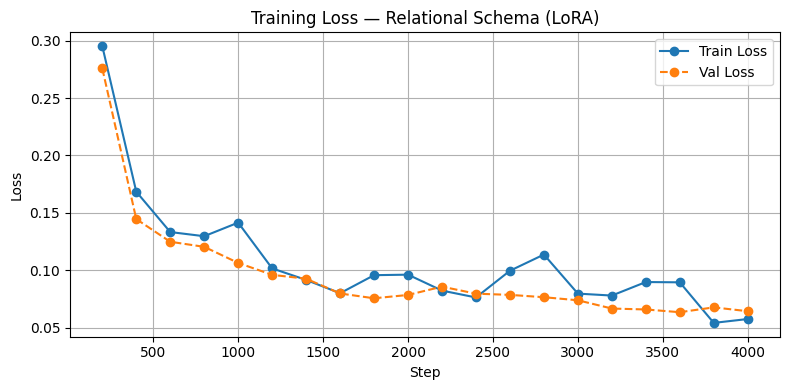

Loss curve saved.


In [28]:
plt.figure(figsize=(8, 4))
plt.plot(history_relational["step"], history_relational["train_loss"], label="Train Loss", marker="o")
plt.plot(history_relational["step"], history_relational["val_loss"], label="Val Loss", marker="o", linestyle="--")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss — Relational Schema (LoRA)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"lora_r{LORA_R}", "training", "loss_curve_relational.png"), dpi=150)
plt.show()
print("Loss curve saved.")

**Observations:**
* Val loss continues improving in epoch 2 (0.0784 -> 0.0642)
* Best val loss of 0.0633 at step 3600
* No clear divergence between train and val loss so no significant overfitting
* Train loss is occasionally above val loss which can be expected with a batch size of 2 (noisy estimates) and dropout is diables during validation, meaning it may be easier to predict.

#### 3.1c — Load Adapted Model

In [29]:
model, tokenizer = load_lora_model_and_tokenizer("relational", rank=LORA_R)
device = "cuda" if torch.cuda.is_available() else "cpu"

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("--- Adapted Model Summary ---")
print(f"Schema: relational")
print(f"Rank (r): {LORA_R}")
print(f"Device: {device}")
print(f"Trainable params: {trainable:,} ({100 * trainable / total:.4f}%)")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

--- Adapted Model Summary ---
Schema: relational
Rank (r): 8
Device: cuda
Trainable params: 0 (0.0000%)


Trainable params is 0 because the model is in inference mode (`model.eval()`)

#### 3.1d — Generate Predictions

In [30]:
if not SKIP_GENERATION:
  predictions_lora_relational = []
  n = len(test_data)
  total_start = time.time()

  for i in range(0, n, INFERENCE_BATCH_SIZE):
    batch = test_data[i:i+INFERENCE_BATCH_SIZE]
    prompts = [build_prompt(e["question"], schema_relational) for e in batch]
    pred_sqls = generate_sql_batch(model, tokenizer, prompts, device)

    for entry, pred_sql in zip(batch, pred_sqls):
      predictions_lora_relational.append({
          "question": entry["question"],
          "gold_sql" : entry["sql"],
          "pred_sql" : pred_sql,
          })

    if i == 0 or (i // INFERENCE_BATCH_SIZE + 1) % 5 == 0:
      elapsed = time.time() - total_start
      print(f"  Batch {i//INFERENCE_BATCH_SIZE + 1}/{(n+INFERENCE_BATCH_SIZE-1)//INFERENCE_BATCH_SIZE} "
            f"| examples {i+1}-{min(i+INFERENCE_BATCH_SIZE, n)}/{n} "
            f"| elapsed: {elapsed/60:.1f} min")

  total_elapsed = time.time() - total_start
  print(f"\nGeneration complete in {total_elapsed/60:.1f} minutes")

  with open(get_predictions_path("relational", "lora_r8"), "w") as f:
    json.dump(predictions_lora_relational, f, indent=2)
  print(f"Saved to {get_predictions_path('relational', 'lora_r8')}")

else:
  with open(get_predictions_path("relational", "lora_r8"), "r") as f:
    predictions_lora_relational = json.load(f)
  print(f"Loaded {len(predictions_lora_relational)} existing predictions")

  print(f"\n---First 3 records:---")
  for i in range(3):
    print(f"Question: {predictions_lora_relational[i]['question']}")
    print(f"Gold SQL: {predictions_lora_relational[i]['gold_sql']}")
    print(f"Pred SQL: {predictions_lora_relational[i]['pred_sql']}\n")

Loaded 402 existing predictions

---First 3 records:---
Question: i need a flight from DENVER to SALT LAKE CITY on monday
Gold SQL: SELECT DISTINCT FLIGHTalias0.FLIGHT_ID FROM AIRPORT_SERVICE AS AIRPORT_SERVICEalias0 , AIRPORT_SERVICE AS AIRPORT_SERVICEalias1 , CITY AS CITYalias0 , CITY AS CITYalias1 , DATE_DAY AS DATE_DAYalias0 , DAYS AS DAYSalias0 , FLIGHT AS FLIGHTalias0 WHERE ( CITYalias1.CITY_CODE = AIRPORT_SERVICEalias1.CITY_CODE AND CITYalias1.CITY_NAME = "SALT LAKE CITY" AND DATE_DAYalias0.DAY_NUMBER = 21 AND DATE_DAYalias0.MONTH_NUMBER = 2 AND DATE_DAYalias0.YEAR = 1991 AND DAYSalias0.DAY_NAME = DATE_DAYalias0.DAY_NAME AND FLIGHTalias0.FLIGHT_DAYS = DAYSalias0.DAYS_CODE AND FLIGHTalias0.TO_AIRPORT = AIRPORT_SERVICEalias1.AIRPORT_CODE ) AND CITYalias0.CITY_CODE = AIRPORT_SERVICEalias0.CITY_CODE AND CITYalias0.CITY_NAME = "DENVER" AND FLIGHTalias0.FROM_AIRPORT = AIRPORT_SERVICEalias0.AIRPORT_CODE;
Pred SQL: , FLalias FLalias FLalias FLaliasaliasaliasaliasaliasaliasaliasaliasalia

**Observations:**
* All predictions are invalid and repeat `FLalias` tokens with no valid SQL structure
* It seems like the model learned schema token patterns (alias names) but failed learn about generating SQL
* This bad result is most likey due to not enough training. It seems like the model started learning the vocab of the ATIS SQL (alias naming), because it saw these tokens repeately during training. but they never learned how to assemble them into valid SQL.

#### 3.1e — Metrics

In [31]:
predictions_lora_relational = compute_per_prediction_metrics(
    predictions_lora_relational, gold_cache
)

with open(get_predictions_path("relational", "lora_r8"), "w") as f:
  json.dump(predictions_lora_relational, f, indent=2)

metrics_lora_relational = aggregate_metrics(predictions_lora_relational)

with open(get_metrics_path("relational", "lora_r8"), "w") as f:
  json.dump(metrics_lora_relational, f, indent=2)

print("\n--- Results: lora | relational ---")
print(f"Exact Match : {metrics_lora_relational['exact_match']}")
print(f"Execution Acc: {metrics_lora_relational['execution_acc']}")
print(f"Exact Set Match: {metrics_lora_relational['exact_set_match']}")
print(f"Record Match Acc: {metrics_lora_relational['record_match_acc']}")
print(f"Exec Errors: {metrics_lora_relational['n_exec_error']}/{metrics_lora_relational['n_total']}")


--- Results: lora | relational ---
Exact Match : 0.0
Execution Acc: 0.0
Exact Set Match: 0.0
Record Match Acc: 0.0
Exec Errors: 402/402


* All 402 predictions failed to execution. All invalid SQL
* This means all metrics are 0. The LoRA adapter performed way worse than the base model

#### 3.1f — Unload Adapted Model

In [32]:
del model
del tokenizer
torch.cuda.empty_cache()
gc.collect()

print("Adapted model unloaded.")
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"GPU memory reserved : {torch.cuda.memory_reserved()/1e9:.2f} GB")

Adapted model unloaded.
GPU memory allocated: 0.01 GB
GPU memory reserved : 3.93 GB


---

### 3.2 CREATE TABLE Schema — Train & Evaluate

#### 3.2a — Train


In [33]:
if not SKIP_TRAINING:
  history_create_table = run_training(schema_name="create_table")
else:
  print("SKIP_TRAINING=True — skipping training, loading existing adapter")
  history_create_table = json.load(
      open(os.path.join(RESULTS_DIR, f"lora_r{LORA_R}", "training", f"train_log_create_table_r{LORA_R}.json"))
  )
  print_training_log(history_create_table, steps_per_epoch=len(train_data) // TRAIN_BATCH_SIZE)

SKIP_TRAINING=True — skipping training, loading existing adapter
Epoch 1 | Step   200 | train loss 0.2665 | val loss 0.2378
Epoch 1 | Step   400 | train loss 0.1363 | val loss 0.1079
Epoch 1 | Step   600 | train loss 0.0925 | val loss 0.0856
Epoch 1 | Step   800 | train loss 0.0969 | val loss 0.0837
Epoch 1 | Step  1000 | train loss 0.1064 | val loss 0.0711
Epoch 1 | Step  1200 | train loss 0.0765 | val loss 0.0680
Epoch 1 | Step  1400 | train loss 0.0785 | val loss 0.0660
Epoch 1 | Step  1600 | train loss 0.0615 | val loss 0.0593
Epoch 1 | Step  1800 | train loss 0.0770 | val loss 0.0533
Epoch 1 | Step  2000 | train loss 0.0779 | val loss 0.0541
Epoch 2 | Step  2200 | train loss 0.0583 | val loss 0.0585
Epoch 2 | Step  2400 | train loss 0.0601 | val loss 0.0549
Epoch 2 | Step  2600 | train loss 0.0730 | val loss 0.0550
Epoch 2 | Step  2800 | train loss 0.0838 | val loss 0.0532
Epoch 2 | Step  3000 | train loss 0.0628 | val loss 0.0522
Epoch 2 | Step  3200 | train loss 0.0669 | val los

#### 3.2b — Training Loss Curve

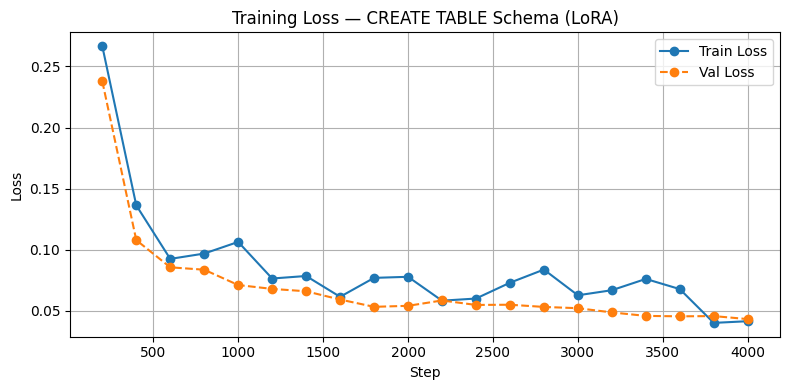

Loss curve saved.


In [34]:
plt.figure(figsize=(8, 4))
plt.plot(history_create_table["step"], history_create_table["train_loss"], label="Train Loss", marker="o")
plt.plot(history_create_table["step"], history_create_table["val_loss"], label="Val Loss", marker="o", linestyle="--")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss — CREATE TABLE Schema (LoRA)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"lora_r{LORA_R}", "training", "loss_curve_create_table.png"), dpi=150)
plt.show()
print("Loss curve saved.")

**Observations:**
* Lower starting loss than relational (0.2665 vs 0.2952).
* The CREATE TABLE format may be easier for the model to learn
* Val loss reaches 0.0433 by step 4000 which is a lower final val loss than relational (0.0642)
* Improvement throughout epoch 2 with no signs of overfitting
* Train loss occasionally exceeds val loss. Same pattern as relational (batch size of 2 and dropout)

#### 3.2c — Load Adapted Model

In [35]:
model, tokenizer = load_lora_model_and_tokenizer("create_table", rank=LORA_R)
device = "cuda" if torch.cuda.is_available() else "cpu"

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("--- Adapted Model Summary ---")
print(f"Schema: CREATE TABLE")
print(f"Rank (r): {LORA_R}")
print(f"Device: {device}")
print(f"Trainable params: {trainable:,} ({100 * trainable / total:.4f}%)")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

--- Adapted Model Summary ---
Schema: CREATE TABLE
Rank (r): 8
Device: cuda
Trainable params: 0 (0.0000%)


#### 3.2d — Generate Predictions

In [36]:
if not SKIP_GENERATION:
  predictions_lora_create_table = []
  n = len(test_data)
  total_start = time.time()

  for i in range(0, n, INFERENCE_BATCH_SIZE):
    batch = test_data[i:i+INFERENCE_BATCH_SIZE]
    prompts = [build_prompt(e["question"], schema_create_table) for e in batch]
    pred_sqls = generate_sql_batch(model, tokenizer, prompts, device)

    for entry, pred_sql in zip(batch, pred_sqls):
      predictions_lora_create_table.append({
          "question": entry["question"],
          "gold_sql" : entry["sql"],
          "pred_sql" : pred_sql,
          })

    if i == 0 or (i // INFERENCE_BATCH_SIZE + 1) % 5 == 0:
      elapsed = time.time() - total_start
      print(f"  Batch {i//INFERENCE_BATCH_SIZE + 1}/{(n+INFERENCE_BATCH_SIZE-1)//INFERENCE_BATCH_SIZE} "
            f"| examples {i+1}-{min(i+INFERENCE_BATCH_SIZE, n)}/{n} "
            f"| elapsed: {elapsed/60:.1f} min")

  total_elapsed = time.time() - total_start
  print(f"\nGeneration complete in {total_elapsed/60:.1f} minutes")

  with open(get_predictions_path("create_table", "lora_r8"), "w") as f:
    json.dump(predictions_lora_create_table, f, indent=2)
  print(f"Saved to {get_predictions_path('create_table', 'lora_r8')}")

else:
  with open(get_predictions_path("create_table", "lora_r8"), "r") as f:
    predictions_lora_create_table = json.load(f)
  print(f"Loaded {len(predictions_lora_create_table)} existing predictions")

  print(f"\n---First 3 records:---")
  for i in range(3):
    print(f"Question: {predictions_lora_create_table[i]['question']}")
    print(f"Gold SQL: {predictions_lora_create_table[i]['gold_sql']}")
    print(f"Pred SQL: {predictions_lora_create_table[i]['pred_sql']}\n")

Loaded 402 existing predictions

---First 3 records:---
Question: i need a flight from DENVER to SALT LAKE CITY on monday
Gold SQL: SELECT DISTINCT FLIGHTalias0.FLIGHT_ID FROM AIRPORT_SERVICE AS AIRPORT_SERVICEalias0 , AIRPORT_SERVICE AS AIRPORT_SERVICEalias1 , CITY AS CITYalias0 , CITY AS CITYalias1 , DATE_DAY AS DATE_DAYalias0 , DAYS AS DAYSalias0 , FLIGHT AS FLIGHTalias0 WHERE ( CITYalias1.CITY_CODE = AIRPORT_SERVICEalias1.CITY_CODE AND CITYalias1.CITY_NAME = "SALT LAKE CITY" AND DATE_DAYalias0.DAY_NUMBER = 21 AND DATE_DAYalias0.MONTH_NUMBER = 2 AND DATE_DAYalias0.YEAR = 1991 AND DAYSalias0.DAY_NAME = DATE_DAYalias0.DAY_NAME AND FLIGHTalias0.FLIGHT_DAYS = DAYSalias0.DAYS_CODE AND FLIGHTalias0.TO_AIRPORT = AIRPORT_SERVICEalias1.AIRPORT_CODE ) AND CITYalias0.CITY_CODE = AIRPORT_SERVICEalias0.CITY_CODE AND CITYalias0.CITY_NAME = "DENVER" AND FLIGHTalias0.FROM_AIRPORT = AIRPORT_SERVICEalias0.AIRPORT_CODE;
Pred SQL: DISTINCT FLalias.FLIGHT0 FLalias.FLIGHT FROMPORT ASPORT0PORT ASPORT FROM

**Observations:**
* Invalid outputs similar to relational LoRA.
- Example 2 shows partial SQL structure (`DISTINCT FLalias.FLIGHT0 FROMPORT...`) suggesting slightly more learned structure than relational LoRA
* With a slightly lower validation loss, it seems like slightly better results

#### 3.2e — Metrics

In [37]:
predictions_lora_create_table = compute_per_prediction_metrics(
    predictions_lora_create_table, gold_cache
)

with open(get_predictions_path("create_table", "lora_r8"), "w") as f:
  json.dump(predictions_lora_create_table, f, indent=2)

metrics_lora_create_table = aggregate_metrics(predictions_lora_create_table)

with open(get_metrics_path("create_table", "lora_r8"), "w") as f:
  json.dump(metrics_lora_create_table, f, indent=2)

print("\n--- Results: lora | create_table ---")
print(f"Exact Match : {metrics_lora_create_table['exact_match']}")
print(f"Execution Acc: {metrics_lora_create_table['execution_acc']}")
print(f"Exact Set Match: {metrics_lora_create_table['exact_set_match']}")
print(f"Record Match Acc: {metrics_lora_create_table['record_match_acc']}")
print(f"Exec Errors: {metrics_lora_create_table['n_exec_error']}/{metrics_lora_create_table['n_total']}")


--- Results: lora | create_table ---
Exact Match : 0.0
Execution Acc: 0.0
Exact Set Match: 0.0
Record Match Acc: 0.0
Exec Errors: 402/402


**Observations:**
* All metrics 0.0 and 402/402 exec errors which is the same complete failure as relational LoRA
* Lower val loss did not translate to significantly better generation quality.

#### 3.2f — Unload Adapted Model

In [38]:
del model
del tokenizer
torch.cuda.empty_cache()
gc.collect()

print("Adapted model unloaded.")
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"GPU memory reserved : {torch.cuda.memory_reserved()/1e9:.2f} GB")

Adapted model unloaded.
GPU memory allocated: 0.01 GB
GPU memory reserved : 5.61 GB


### 3.3 Layer 2 Results Summary

* Results from the two LoRA-adapted model evaluations consolidated into one table.
* Each schema format is compared against its corresponding base model result from Section 2.

In [39]:
lora_results = {
    "Schema": ["Relational", "CREATE TABLE"],
    "EM (Base)": [metrics_base_relational["exact_match"], metrics_base_create_table["exact_match"]],
    "EM (LoRA)": [metrics_lora_relational["exact_match"], metrics_lora_create_table["exact_match"]],
    "EX (Base)": [metrics_base_relational["execution_acc"], metrics_base_create_table["execution_acc"]],
    "EX (LoRA)": [metrics_lora_relational["execution_acc"], metrics_lora_create_table["execution_acc"]],
    "ESM (Base)": [metrics_base_relational["exact_set_match"], metrics_base_create_table["exact_set_match"]],
    "ESM (LoRA)": [metrics_lora_relational["exact_set_match"], metrics_lora_create_table["exact_set_match"]],
    "RMA (Base)": [metrics_base_relational["record_match_acc"], metrics_base_create_table["record_match_acc"]],
    "RMA (LoRA)": [metrics_lora_relational["record_match_acc"], metrics_lora_create_table["record_match_acc"]],
    "Exec Errors (Base)": [metrics_base_relational["n_exec_error"], metrics_base_create_table["n_exec_error"]],
    "Exec Errors (LoRA)": [metrics_lora_relational["n_exec_error"], metrics_lora_create_table["n_exec_error"]],
}

df_layer2 = pd.DataFrame(lora_results).set_index("Schema")
print("--- Layer 2: Base vs LoRA Results ---")
print(df_layer2.to_string())

--- Layer 2: Base vs LoRA Results ---
              EM (Base)  EM (LoRA)  EX (Base)  EX (LoRA)  ESM (Base)  ESM (LoRA)  RMA (Base)  RMA (LoRA)  Exec Errors (Base)  Exec Errors (LoRA)
Schema                                                                                                                                          
Relational          0.0        0.0     0.0522        0.0         0.0         0.0      0.0821         0.0                  83                 402
CREATE TABLE        0.0        0.0     0.0597        0.0         0.0         0.0      0.0945         0.0                  51                 402


**Observations:**
* LoRA adaptation resulted in worse performance across both schemas, with all metrics being 0.0
* The base model outperforms LoRA on all metrics despite never being trained on ATIS data
* Insufficient training (2 epochs) is most likely the primary cause. The model just started to learn the ATIS SQL patterns but did not converge enough to generate valid SQL
* The CREATE TABLE base model had the best overall performance across all experiments (EX: 5.97%, RMA: 9.45%)

---
## Section 4 — Demo

Interactive demo of the text-to-SQL pipeline.
1. Enter a natural language question about airline flights and the base model will generate a SQL query using the relational schema.
2. You can change `schema_relational` to the other schema formats as well (`schema_create_table`, `schema_json`, `schema_nl`)
> **Note:** Run Section 4.1 to load the model before running the demo.

In [40]:
# Load base model for demo
# Skip this cell if model is already loaded from Section 2.1
model, tokenizer = load_base_model_and_tokenizer()
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Model ready for demo.")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model ready for demo.


Here are example questions:
* "how many flights does NW have leaving IAD"
* "what airlines fly into boston?"
* "show me all flights from chicago to dallas"
* "show me united airlines flights from seattle to denver"



In [41]:
# --- Input your question here ---
question = "what airports are in california?"

# --- Build and display prompt ---
prompt = build_prompt(question, schema_relational)  # you can change the schema format here

print(f"Question : {question}")
print(f"\n--- Prompt sent to model ---")
print(prompt)
print(f"--- End of prompt ---\n")

# --- Generate SQL ---
pred_sql = generate_sql(model, tokenizer, prompt, device)
print(f"Generated SQL : {pred_sql}")

# --- Execute against database ---
conn = sqlite3.connect(DB_PATH)
result = execute_sql(pred_sql, conn)
conn.close()

if result:
  print(f"\nQuery returned {len(result)} rows (showing first 10):")
  display(pd.DataFrame(result[:10]))
else:
  print("\nResult: Query failed to execute")

Question : what airports are in california?

--- Prompt sent to model ---
Translate the following question into SQL.

Schema:
aircraft(aircraft_code, aircraft_description, manufacturer, basic_type, engines, propulsion, wide_body, wing_span, length, weight, capacity, pay_load, cruising_speed, range_miles, pressurized)
airline(airline_code, airline_name, note)
airport(airport_code, airport_name, airport_location, state_code, country_name, time_zone_code, minimum_connect_time)
airport_service(city_code, airport_code, miles_distant, direction, minutes_distant)
city(city_code, city_name, state_code, country_name, time_zone_code)
class_of_service(booking_class, rank, class_description)
code_description(code, description)
compartment_class(compartment, class_type)
date_day(month_number, day_number, year, day_name)
days(days_code, day_name)
dual_carrier(main_airline, low_flight_number, high_flight_number, dual_airline, service_name)
equipment_sequence(aircraft_code_sequence, aircraft_code)
far

,0
0,BUR
1,LAX
2,LGB
3,OAK
4,ONT
5,SAN
6,SFO
7,SJC
